# 01 — Data Acquisition

**Project:** VolatilityRegimes — Emerging Market Volatility Modeling 

**Purpose:** Pull raw time-series data from three sources (Banxico, Yahoo Finance, FRED), verify the API calls work, persist to `data/raw/`, and produce a visual sanity check.  

**Output:** Three CSV files under DVC control; three plots confirming data integrity.

**Outline:**

0. Setup
1. MXN/USD — Banxico FIX Rate
2. IPC Index — Yahoo Finance
3. Macro Indicators — FRED
4. Sanity Check — Load CSVs and Plot

--- 
---
## 0. Setup

All imports live in one cell at the top. `ROOT` points to the project root so every subsequent path is absolute and works regardless of where the notebook is opened from.

In [1]:
import os
import sys
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

---
---
## 1. MXN/USD — Banxico FIX Rate

**Source:** Banco de México SIE API, series `SF43718`  
**Why Banxico over Yahoo Finance for the peso:** This is the official FIX rate — the legally binding reference rate used to settle foreign-currency obligations in Mexico. Third-party aggregators introduce holiday gaps and rounding artifacts that the official source does not have.  
**Token:** stored in `.env`, never committed to git.

In [2]:
BANXICO_TOKEN = os.getenv("BANXICO_TOKEN")

series = "SF43718"
start  = "2000-01-01"
end    = "2025-03-01"

url     = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{series}/datos/{start}/{end}"
headers = {"Bmx-Token": BANXICO_TOKEN}

response = requests.get(url, headers=headers)

print("Status:", response.status_code)
print("URL hit:", response.url)
print("Response preview:")
response.json()

Status: 200
URL hit: https://www.banxico.org.mx/SieAPIRest/service/v1/series/SF43718/datos/2000-01-01/2025-03-01
Response preview:


{'bmx': {'series': [{'idSerie': 'SF43718',
    'titulo': 'Tipo de cambio                                          Pesos por dólar E.U.A. Tipo de cambio para solventar obligaciones denominadas en moneda extranjera Fecha de determinación (FIX)',
    'datos': [{'fecha': '03/01/2000', 'dato': '9.3949'},
     {'fecha': '04/01/2000', 'dato': '9.4564'},
     {'fecha': '05/01/2000', 'dato': '9.5455'},
     {'fecha': '06/01/2000', 'dato': '9.5705'},
     {'fecha': '07/01/2000', 'dato': '9.5150'},
     {'fecha': '10/01/2000', 'dato': '9.4464'},
     {'fecha': '11/01/2000', 'dato': '9.4780'},
     {'fecha': '12/01/2000', 'dato': '9.5352'},
     {'fecha': '13/01/2000', 'dato': '9.5057'},
     {'fecha': '14/01/2000', 'dato': '9.4483'},
     {'fecha': '17/01/2000', 'dato': '9.4172'},
     {'fecha': '18/01/2000', 'dato': '9.4383'},
     {'fecha': '19/01/2000', 'dato': '9.4086'},
     {'fecha': '20/01/2000', 'dato': '9.4038'},
     {'fecha': '21/01/2000', 'dato': '9.4463'},
     {'fecha': '24/01/2000'

---
---
## 2. IPC Index — Yahoo Finance (Direct HTTP Request)

**Ticker:** `^MXX` (S&P/BMV IPC)  
**Why:** The IPC is Mexico's main equity benchmark (35 most liquid BMV stocks). We use it alongside the exchange rate to capture both currency and equity volatility dynamics.  

**Why not `yfinance.download()`:** yfinance wraps the Yahoo Finance API but has a known bug with the `^MXX` ticker — it returns an empty DataFrame with a `No timezone found` error. The underlying Yahoo Finance endpoint works correctly when called directly with a standard `User-Agent` header. This is what `fetch.py` does.

In [3]:
url = "https://query1.finance.yahoo.com/v8/finance/chart/%5EMXX"
params  = {"interval": "1d", "range": "25y"}
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, params=params, headers=headers)
response.raise_for_status()
raw = response.json()

# Parse timestamps and closing prices from the JSON response
timestamps = raw["chart"]["result"][0]["timestamp"]
closes     = raw["chart"]["result"][0]["indicators"]["quote"][0]["close"]

ipc_raw = pd.DataFrame({"IPC": closes},
                        index=pd.to_datetime(timestamps, unit="s"))
ipc_raw.index.name = "Date"
ipc_raw.index = ipc_raw.index.normalize()

print(f"{len(ipc_raw):,} rows  |  {ipc_raw.index.min().date()} → {ipc_raw.index.max().date()}")
print(ipc_raw.head())

6,338 rows  |  2001-03-13 → 2026-03-13
                    IPC
Date                   
2001-03-13  5991.950195
2001-03-14  5813.839844
2001-03-15  5792.709961
2001-03-16  5878.569824
2001-03-19  5935.220215


---
---
## 3. Macro Indicators — FRED

**Series:** `VIXCLS` (VIX), `DFF` (Fed Funds Rate), `T10Y2Y` (10Y–2Y yield spread)  
**Why these three:** They are the external risk factors that drive peso volatility from outside Mexico. The VIX is especially important — empirically, MXN/USD responds faster to VIX spikes than almost any other major currency pair. The yield spread captures US recession risk, which historically triggers capital flight from emerging markets.

In [4]:
from fredapi import Fred

fred = Fred(api_key=os.getenv("FRED_API_KEY"))
vix  = fred.get_series("VIXCLS", observation_start="2000-01-01")
vix.head()

2000-01-03    24.21
2000-01-04    27.01
2000-01-05    26.41
2000-01-06    25.73
2000-01-07    21.72
dtype: float64

---
---
## 4. Sanity Check — Load CSVs and Plot

We load directly from the saved CSVs (not from memory) to verify the files on disk are correct.  

**What correct data looks like:**
- MXN/USD ~9–10 pesos in 2000, rising to ~17 after the 2016 Trump shock, ~25 during COVID 2020
- IPC growing from ~6,000 in 2000 to ~55,000+ by 2024
- VIX spiking sharply in 2008–09 and March 2020

If any series looks flat, truncated, or wrong — **stop here**. Downstream models will silently train on corrupted data.

MXN/USD : 6,589 rows  |  2000-01-03 → 2026-03-06
IPC     : 6,337 rows  |  2001-03-06 → 2026-03-06
Macro   : 9,562 rows  |  2000-01-01 → 2026-03-06


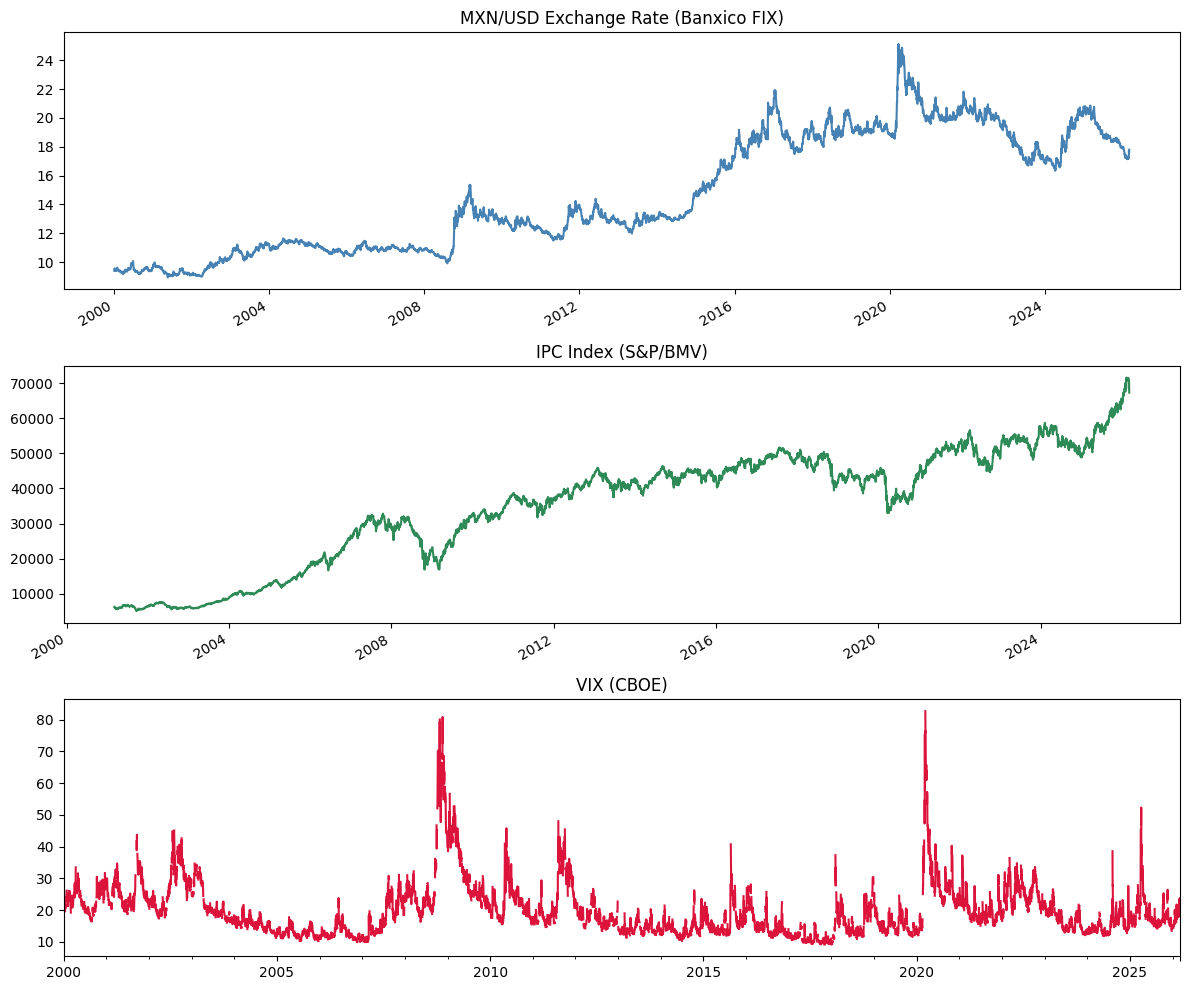

In [5]:
mxn   = pd.read_csv(ROOT / "data/raw/mxn_usd.csv", index_col="Date", parse_dates=True)
ipc   = pd.read_csv(ROOT / "data/raw/ipc.csv",      index_col="Date", parse_dates=True)
macro = pd.read_csv(ROOT / "data/raw/macro.csv",     index_col=0,      parse_dates=True)

print(f"MXN/USD : {mxn.shape[0]:,} rows  |  {mxn.index.min().date()} → {mxn.index.max().date()}")
print(f"IPC     : {ipc.shape[0]:,} rows  |  {ipc.index.min().date()} → {ipc.index.max().date()}")
print(f"Macro   : {macro.shape[0]:,} rows  |  {macro.index.min().date()} → {macro.index.max().date()}")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

mxn.plot(  ax=axes[0], title="MXN/USD Exchange Rate (Banxico FIX)",  color="steelblue", legend=False)
ipc.plot(  ax=axes[1], title="IPC Index (S&P/BMV)",                  color="seagreen",  legend=False)
macro["VIXCLS"].plot(ax=axes[2], title="VIX (CBOE)",                 color="crimson",   legend=False)

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()
plt.show()